### Análise Exploratória de Dados (EDA)

Arquivos esperados em `../outputs/processed/`:
- dengue_municipios.parquet
- chik_municipios.parquet

## Imports e configuração

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/processed", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)


## Leitura dos dados processados

In [3]:

deng_casos  = pd.read_parquet("../outputs/processed/dengue_municipios.parquet")
chik_casos = pd.read_parquet("../outputs/processed/chik_municipios.parquet")
deng = glob.glob("../data/raw/dengue_sinan/*.parquet")
chik = glob.glob("../data/raw/chikungunya_sinan/*.parquet")

pop = pd.read_excel("../data/raw/municipios_ibge/POP2025_20260113.xls")

## Distribuição temporal

In [10]:
def analise_temporal(df, nome):

    df_final = df.copy()

    df_final["NU_ANO"] = pd.to_numeric(
        df_final["NU_ANO"],
        errors="coerce"
    )

    ano_min = int(df_final["NU_ANO"].min())
    ano_max = 2026

    df_final = df_final[
        df_final["NU_ANO"]
        .between(
            ano_min,
            ano_max
        )
    ]

    df_final = (
        df_final["NU_ANO"]
        .value_counts()
        .sort_index()
    )

    print(df_final)

    print("\nPeríodo detectado:")
    print(f"{ano_min} → {ano_max}")

    print("\nEstatísticas descritivas:")
    print(df_final.describe())

    plt.figure()

    df_final.plot(marker='o')

    plt.title(
        f"Análise Temporal dos Casos ({nome})"
    )

    plt.xlabel("Ano")

    plt.ylabel(
        "Número de Casos"
    )

    plt.grid()

    plt.tight_layout()

    plt.savefig(
        f"../outputs/figures/grafico_temporal_{nome}.png",
        dpi=300
    )

    plt.show()

    return df_final


## Evolução Top 10 municípios

In [1]:
def analise_espaco_temporal(df, regiao, nome):

    df_esp = df[df["Região"] == regiao]

    top10 = df_esp["Município"].value_counts().head(10).reset_index()
    top10.columns = ["Município", "qtd"]

    top_mun = top10["Município"]

    df_top = df_esp[df_esp["Município"].isin(top_mun)]

    df_group = df_top.groupby(["NU_ANO", "Município"]).size().unstack(fill_value=0)

    df_group.plot(figsize=(10,5), marker='o')

    plt.title(f"Evolução dos Casos - Top 10 Municípios do {regiao}")
    plt.xlabel("Ano")
    plt.ylabel("Casos")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid()

    plt.savefig(
        f"../outputs/figures/analise_espaco_temporal_{nome}_{regiao}.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    return df_group

df = analise_espaco_temporal(deng_casos, 'Nordeste', "Nordeste")

NameError: name 'deng_casos' is not defined

## Top 10 municípios

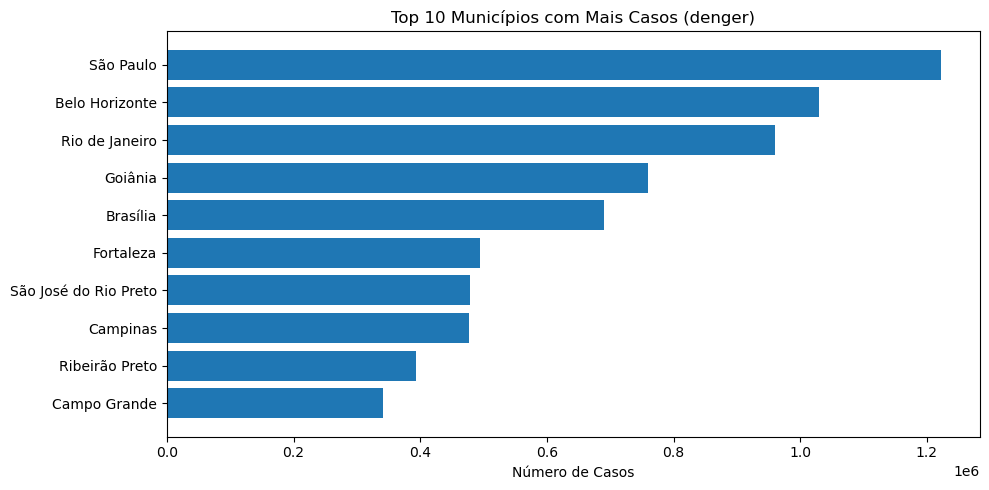

,Município,qtd
0,São Paulo,1222919
1,Belo Horizonte,1029227
2,Rio de Janeiro,959797
3,Goiânia,759466
4,Brasília,690948
5,Fortaleza,494410
6,São José do Rio Preto,478989
7,Campinas,477607
8,Ribeirão Preto,393877
9,Campo Grande,341343


In [18]:
import matplotlib.pyplot as plt

def top10_municipios(df, nome):

    top10 = df["Município"].value_counts().head(10).reset_index()
    top10.columns = ["Município", "qtd"]

    plt.figure(figsize=(10,5))
    plt.barh(top10["Município"], top10["qtd"])

    plt.xlabel("Número de Casos")
    plt.title(f"Top 10 Municípios com Mais Casos ({nome})")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.savefig(f"../outputs/figures/top10_municipios_{nome}.png", dpi=300)

    plt.show()

    return top10

top10_municipios(deng_casos, "denger")

## Análise de Sazonalidade

Processando: ../data/raw/chikungunya_sinan/CHIKBR15.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR16.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR17.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR18.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR19.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR20.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR21.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR22.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR23.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR24.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR25.parquet
Processando: ../data/raw/chikungunya_sinan/CHIKBR26.parquet


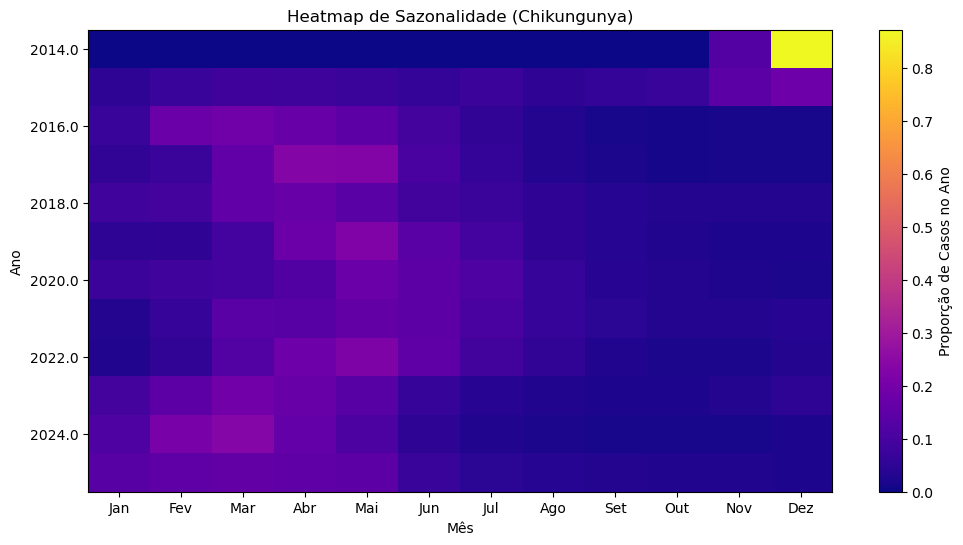

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob


def heatmap_sazonalidade_normalizado(base, nome,cidade):

    lista = []

    for i in base:

        print(f"Processando: {i}")

        df = pd.read_parquet(i, columns=["DT_SIN_PRI", "Município"])

        df["DT_SIN_PRI"] = pd.to_datetime(df["DT_SIN_PRI"], format="%Y%m%d", errors="coerce")

        df["ANO"] = df["DT_SIN_PRI"].dt.year
        df["MES"] = df["DT_SIN_PRI"].dt.month

        df = df[df["ANO"].between(2000, 2025)]

        lista.append(df[["ANO", "MES"]])

        del df


    df_final = pd.concat(lista, ignore_index=True)

    tabela = df_final.groupby(["ANO", "MES"]).size().unstack(fill_value=0)

    tabela[tabela < 50] = 0

    tabela = tabela[tabela.sum(axis=1) > 0]   


    tabela_normalizada = tabela.div(tabela.sum(axis=1), axis=0)

    plt.figure(figsize=(12,6))

    plt.imshow(tabela_normalizada, aspect="auto", cmap="plasma")

    plt.colorbar(label="Proporção de Casos no Ano")

    plt.title(f"Heatmap de Sazonalidade ({nome})")

    plt.xlabel("Mês")
    plt.ylabel("Ano")

    plt.xticks(
        ticks=range(12),
        labels=["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
    )

    anos = tabela_normalizada.index

    plt.yticks(
        ticks=range(0, len(anos), 2),
        labels=anos[::2]
    )

    plt.savefig(f"../outputs/figures/heatmap_sazonalidade{nome}.png", dpi=300, bbox_inches="tight")

    plt.show()

    return tabela_normalizada


heatmap = heatmap_sazonalidade_normalizado(chik, "Chikungunya")

In [ ]:
df = pd.read_parquet(chik[1], columns=["DT_SIN_PRI"])
df["DT_SIN_PRI"] = pd.to_datetime(df["DT_SIN_PRI"], format="%Y%m%d", errors="coerce")

df["ANO"] = df["DT_SIN_PRI"].dt.year
df["MES"] = df["DT_SIN_PRI"].dt.month



DT_SIN_PRI  ANO     MES
2016-03-01  2016.0  3.0    2698
2016-02-20  2016.0  2.0    2672
2016-02-22  2016.0  2.0    2598
2016-02-15  2016.0  2.0    2520
2016-03-10  2016.0  3.0    2395
                           ... 
2006-05-07  2006.0  5.0       1
2006-05-15  2006.0  5.0       1
2006-05-25  2006.0  5.0       1
2006-08-04  2006.0  8.0       1
2008-03-11  2008.0  3.0       1
Name: count, Length: 1752, dtype: int64

## Análise de sazonalidade por cidade

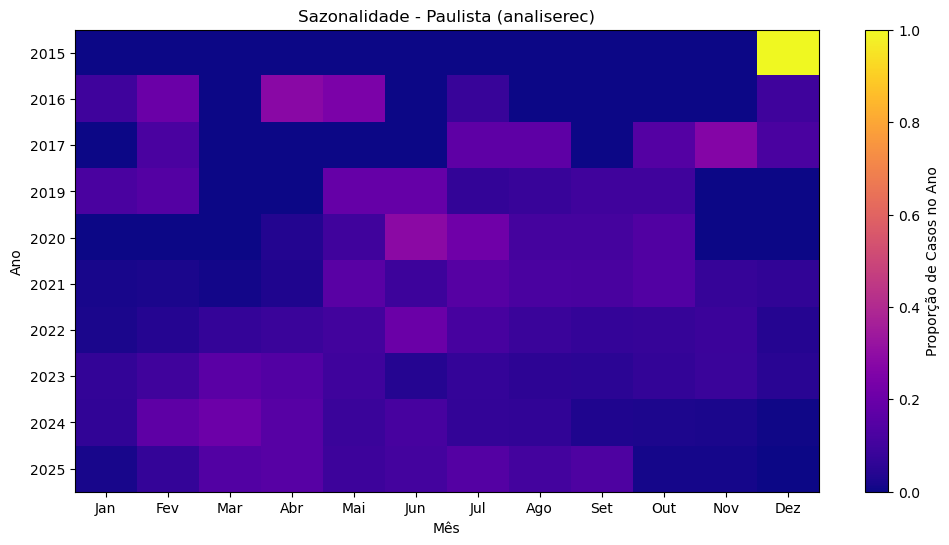

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


def sazonalidade_por_cidade(df, municipio, nome):

    df_cidade = df[
        df["Município"] == municipio
    ].copy()

    df_cidade["DT_SIN_PRI"] = pd.to_datetime(
        df_cidade["DT_SIN_PRI"],
        format="%Y%m%d",
        errors="coerce"
    )

    df_cidade = df_cidade.dropna(
        subset=["DT_SIN_PRI"]
    )

    df_cidade["ANO"] = (
        df_cidade["DT_SIN_PRI"]
        .dt.year
    )

    df_cidade["MES"] = (
        df_cidade["DT_SIN_PRI"]
        .dt.month
    )

    if nome.lower() == "chik":
        df_cidade = df_cidade[
            df_cidade["ANO"]
            .between(2014, 2025)
        ]
    else:
        df_cidade = df_cidade[
            df_cidade["ANO"]
            .between(2000, 2025)
        ]

    tabela = (
        df_cidade
        .groupby(["ANO", "MES"])
        .size()
        .unstack(fill_value=0)
    )

    tabela[tabela < 5] = 0

    tabela = tabela.reindex(
        columns=range(1, 13),
        fill_value=0
    )

    tabela = tabela[
    tabela.sum(axis=1) > 0]

    tabela_normalizada = tabela.div(
        tabela.sum(axis=1),
        axis=0
    )

    plt.figure(figsize=(12, 6))

    plt.imshow(
        tabela_normalizada,
        aspect="auto",
        cmap="plasma"
    )

    plt.colorbar(
        label="Proporção de Casos no Ano"
    )

    plt.title(
        f"Sazonalidade - {municipio} ({nome})"
    )

    plt.xlabel("Mês")
    plt.ylabel("Ano")

    plt.xticks(
        ticks=range(12),
        labels=[
            "Jan", "Fev", "Mar", "Abr",
            "Mai", "Jun", "Jul", "Ago",
            "Set", "Out", "Nov", "Dez"
        ]
    )

    anos = tabela_normalizada.index

    plt.yticks(
        ticks=range(len(anos)),
        labels=anos
    )

    plt.grid(False)

    plt.savefig(
        f"../outputs/figures/"
        f"sazonalidade_{nome}_{municipio}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return tabela_normalizada

df = sazonalidade_por_cidade(chik_casos, "Paulista", "analiserec")

In [ ]:
import pandas as pd


def calcular_incidencia(df_casos, df_pop, nome):

    df = df_casos.copy()

    df["Município"] = (
        df["Município"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df_pop["Município"] = (
        df_pop[
            "BRASIL E UNIDADES DA FEDERAÇÃO"
        ]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df_pop["POPULACAO"] = (
        df_pop["POPULAÇÃO ESTIMADA"]
    )

    casos = (
        df.groupby("Município")
        .size()
        .reset_index(name="CASOS")
    )

    incidencia = casos.merge(
        df_pop[
            ["Município", "POPULACAO"]
        ],
        on="Município",
        how="left"
    )

    incidencia["INCIDENCIA_100K"] = (
        incidencia["CASOS"]
        / incidencia["POPULACAO"]
    ) * 100000

    incidencia = incidencia.sort_values(
        "INCIDENCIA_100K",
        ascending=False
    )

    incidencia.to_parquet(
        f"../outputs/processed/incidencia_{nome}.parquet",
        index=False
    )

    return incidencia

df = calcular_incidencia(deng_casos, pop, "inc")